# Statistical Analysis of Pupil Data

```{admonition} Overview
PupEyes is designed for **preprocessing**, namely preparing your pupil data in an analysis-friendly format so you can perform whatever analyses that you deem appropriate for your research goals. Indeed, there are [many ways to analyze pupil size data](https://link.springer.com/book/10.1007/978-3-031-54896-3), and it would be impractical to implement them all. This tutorial seeks to demonstrate how easily you can conduct analyses with preprocessed `PupEyes` data.

We'll cover two basic approaches to analyzing task-evoked pupillary responses:

1. **Using a Predefined Time Window**

2. **Cluster-based Permutation Testing**

```

```{note} 
Some analyses in this tutorial require the `mne` package, a Python library for visualizing and analyzing neurophysiological data. `mne` is not included as a dependency for PupEyes. For information on how to install, see: https://mne.tools/stable/install/index.html
```

## Load Data

We will load our preprocessed data from the [Pupil Preprocessing](pupil_preproc.ipynb) tutorial.

In [36]:
import pandas as pd
import pupeyes as pe

%matplotlib inline

In [37]:
# use .load() to load the .pkl file
p = pe.PupilProcessor.load('example_data/myproject.pkl')
# show preview
p.final_data.head(5)

,participant,block,trial,event,trialtime,x,y,pp_final,eventtime,group
0,sub001,A,1,stimulus,984,957.8,490.3,10.388466,0,A
1,sub001,A,1,stimulus,985,957.9,489.3,10.832381,1,A
2,sub001,A,1,stimulus,986,958.0,488.5,11.266722,2,A
3,sub001,A,1,stimulus,987,958.1,488.3,11.691389,3,A
4,sub001,A,1,stimulus,988,958.0,488.8,12.106379,4,A


## Use a Predefined Time Window

If you have a hypothesis for when your task-evoked pupillary response will emerge, you can simply select that time window and compute the mean pupil size within that window.

For example, if we hypothesize that the effect emerges after 600 ms after stimulus onset:

In [40]:
p.after600 = p.final_data.query('eventtime > 600').groupby(['group','participant','block','trial']).pp_final.mean() 
p.after600

group  participant  block  trial
A      sub001       A      1        286.092929
                           2        106.920536
                           4        -23.424129
                           5        -109.87721
                           7       -155.322744
                           9         -75.42438
                           10          41.4242
       sub002       A      2         65.600603
                           3        -82.183508
                           4         27.141702
                           5         10.128819
                           6        -113.35635
                           7         -95.71904
                           8        183.516865
                           9       -173.823245
                           10      -128.505268
B      sub003       A      1        -14.644977
                           2         95.105912
                           3       -238.089714
                           4        -121.43069
                           

From now on, mean pupil sizes can be analyzed in the same way as response times (RTs).

## Plot Evoked Response

Oftentimes we do not have a hypothesis about when an effect should emerge. Even if we do, it is always nice to have a plot showing the entire evoked response. PupEyes has a built-in method, `.plot_evoked()`, to plot evoked responses. 

Condition {'group': 'A'}: 16 trials. Minimum samples: 2997
Condition {'group': 'B'}: 19 trials. Minimum samples: 2998


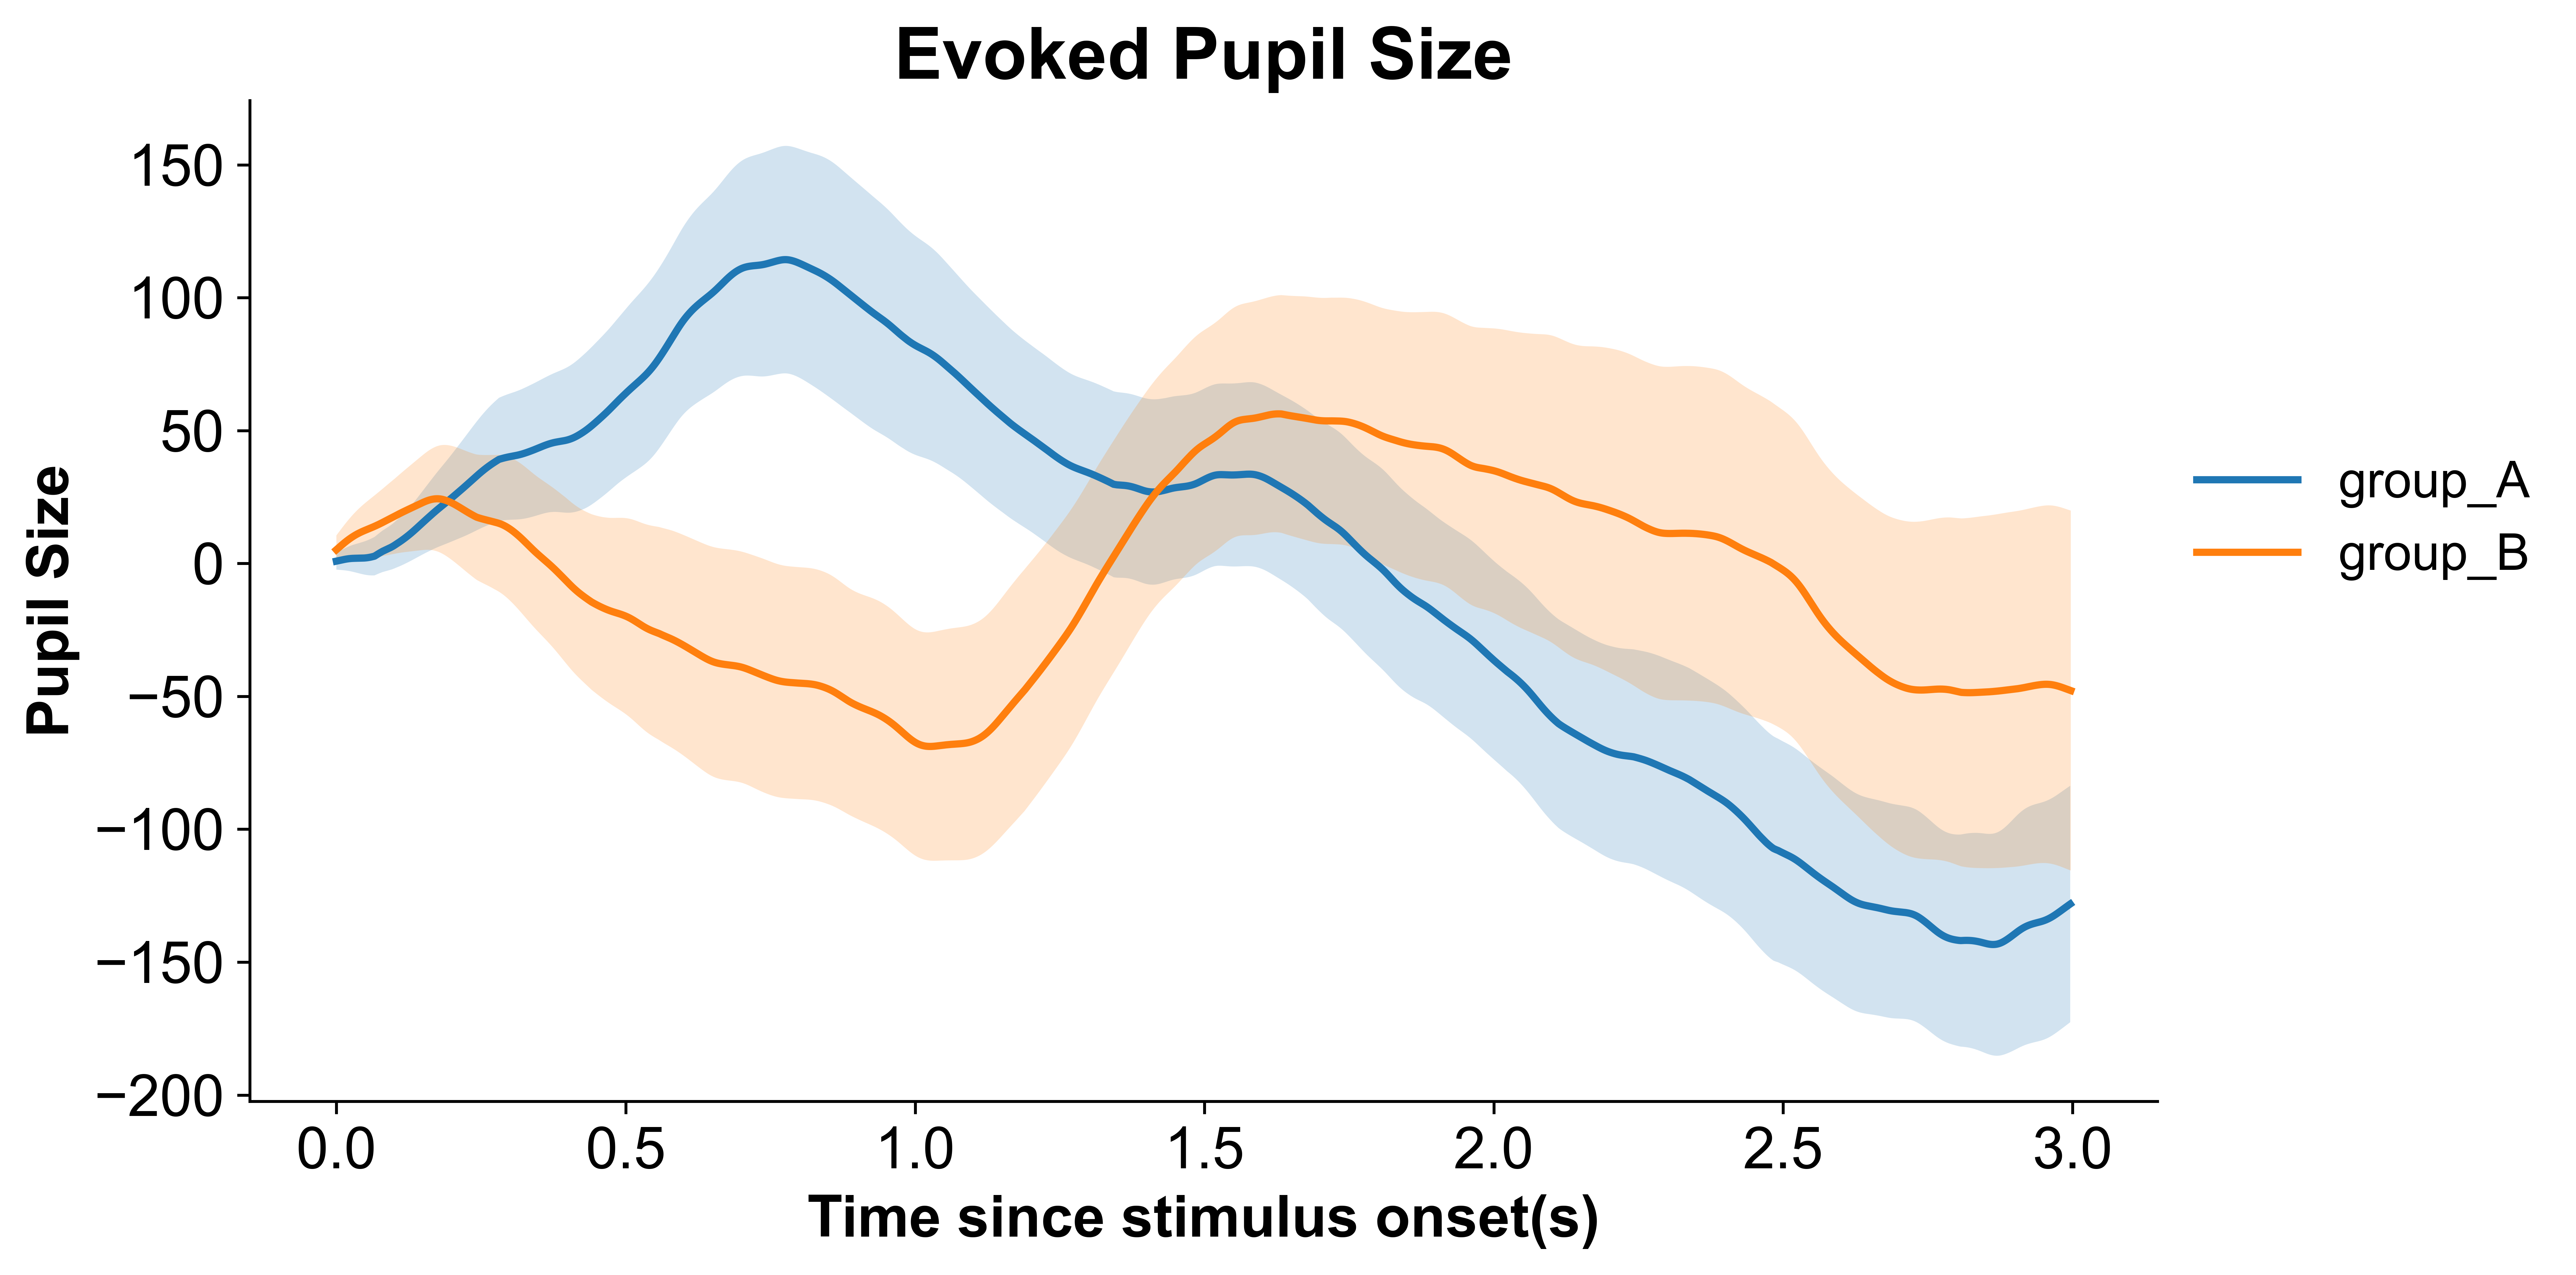

In [43]:
test_array, (fig, ax) = p.plot_evoked(data='final_data', condition='group', pupil_col='pp_final', error='sem')